## Summary

This project builds an improved house price prediction system using the 
California Housing dataset, comparing multiple models instead of relying 
on just one like in Task 1.

Features were scaled using StandardScaler so that no single feature (like 
Population) dominates the model just because it has bigger numbers than 
others (like Income).

Three models were trained and compared: Linear Regression, Ridge 
Regression, and Decision Tree. Each was evaluated using RMSE and R² on 
unseen test data.

Decision Tree performed the best, with a Test R² of 0.600 compared to 
0.576 for both Linear Regression and Ridge Regression. Ridge performed 
almost identically to Linear Regression, suggesting regularization had 
very little effect on this dataset. The train vs test comparison also 
showed Decision Tree's gap between training and test performance wasn't 
much larger than the other two models, meaning it wasn't overfitting 
significantly despite being more flexible.

In [32]:
# Import libraries that handles data manipulation, model training, evaluation, and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [33]:
# Load the dataset as a pandas DataFrame (as_frame=True gives us labelled columns)
data = fetch_california_housing(as_frame=True)

# Combine the feature (data.data) with the target column(houseprice), renaming it clearly
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [34]:
# In Machine learning model requires input feature(x) and an output variable(y) to be handled separately

x = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

In [35]:
# Scale features so no single feature dominates due to its numeric range

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [36]:
# train-test split so that model is evaluated using unseen data rather than memorizing values

x_train, x_test, y_train, y_test = train_test_split(
     x_scaled, y, test_size=0.2, random_state=42
)

In [37]:
# Linear Regression serves as a baseline, Ridge Regression helps reduce overfitting and Decision Tree captures non-linear relationships

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5)
}

In [38]:
# RMSE and R² are measured for better model evaluation and comparison

results = {}

for name, model in models.items():
    model.fit(x_train, y_train)
    predictions = model.predict(x_test)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results[name]  = {
         "RMSE": rmse,
         "R2_Score": r2
    }

    results_df = pd.DataFrame(results).T
    results_df

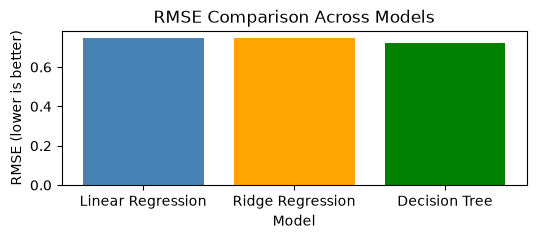

In [39]:
# Visualize RMSE for each model side by side

plt.figure(figsize=(6,2))
plt.bar(results_df.index, results_df["RMSE"], color=['steelblue', 'orange', 'green'])
plt.title("RMSE Comparison Across Models")
plt.ylabel("RMSE (lower is better)")
plt.xlabel("Model")
plt.show()

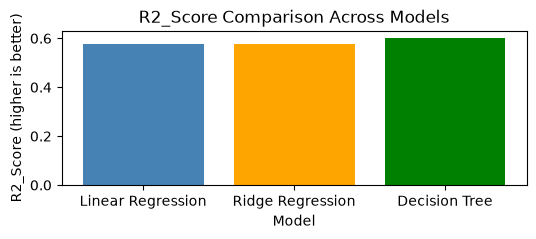

In [40]:
# Visualize R2 score for each model side by side

plt.figure(figsize=(6,2))
plt.bar(results_df.index, results_df["R2_Score"], color=['steelblue', 'orange', 'green'])
plt.title("R2_Score Comparison Across Models")
plt.ylabel("R2_Score (higher is better)")
plt.xlabel("Model")
plt.show()

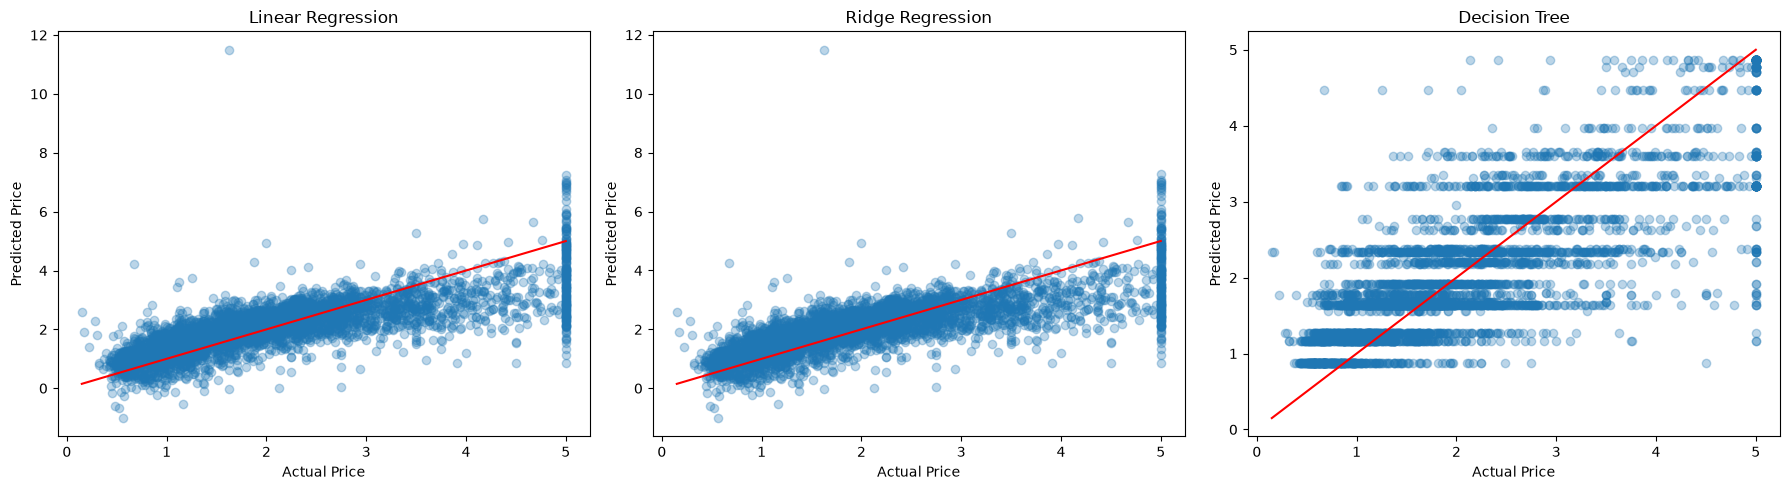

In [41]:
# Compare all three models, points closer to red line mean more accurate predictions

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, (name, model) in zip(axes, models.items()):
    preds = model.predict(x_test)
    ax.scatter(y_test, preds, alpha=0.3)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
    ax.set_title(name)
    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")

plt.tight_layout()
plt.show()

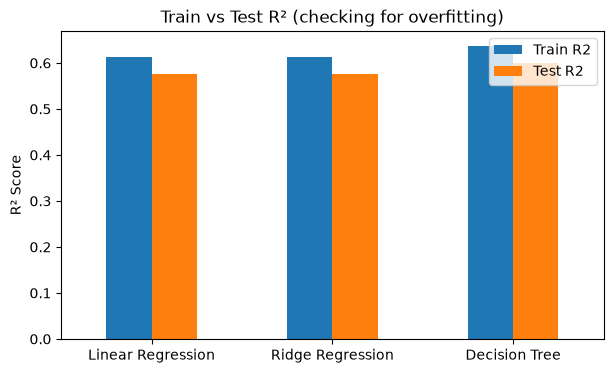

,Train R2,Test R2
Linear Regression,0.612551,0.575788
Ridge Regression,0.612551,0.575819
Decision Tree,0.637679,0.599732


In [42]:
# Compare R2 score on training data vs test data for each model

train_test_scores = {}

for name, model in models.items():
    train_r2 = r2_score(y_train, model.predict(x_train))
    test_r2 = r2_score(y_test, model.predict(x_test))
    train_test_scores[name] = {"Train R2": train_r2, "Test R2": test_r2}

scores_df = pd.DataFrame(train_test_scores).T
scores_df.plot(kind='bar', figsize=(7,4))
plt.title("Train vs Test R² (checking for overfitting)")
plt.ylabel("R² Score")
plt.xticks(rotation=0)
plt.show()

scores_df

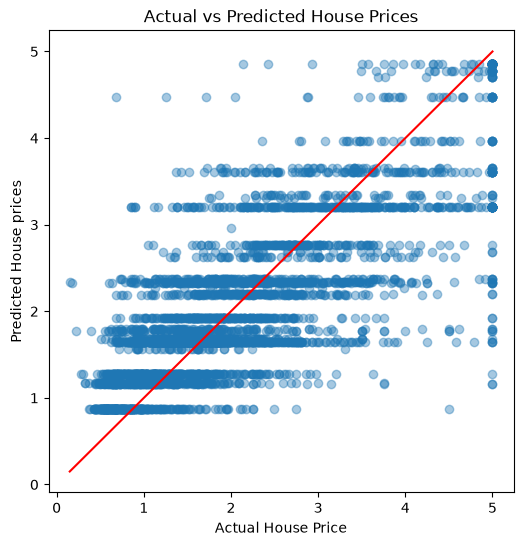

In [31]:
# Automatically select whichever model had the highest R2 score on test data

best_model_name = results_df["R2_Score"].idxmax()
best_model = models[best_model_name]
best_model.fit(x_train, y_train)

y_pred = best_model.predict(x_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House prices")
plt.title("Actual vs Predicted House Prices")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")
plt.show()           